### Install packages and prepare dataset

In [1]:
!pip install tensorflow==2.16.1 keras==3.0.5


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
import os
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "dataset_2D/Training"
test_dir = "dataset_2D/Testing"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2870 files belonging to 4 classes.
Found 394 files belonging to 4 classes.


In [4]:
class_names = train_dataset.class_names
print(class_names)
def convert_to_binary(images, labels):
    
    no_tumor_index = class_names.index('no_tumor')
    
    binary_labels = tf.where(labels == no_tumor_index, 0, 1)
    return images, binary_labels

train_dataset = train_dataset.map(convert_to_binary)
test_dataset = test_dataset.map(convert_to_binary)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [5]:
val_size = 0.2

train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = int(val_size * train_batches)

val_dataset = train_dataset.take(val_batches)
train_dataset = train_dataset.skip(val_batches)

### Tune the system, define and train the model

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [7]:
for imgs, labels in train_dataset.take(1):
    print("Label dtype:", labels.dtype)
    print("Label min:", tf.reduce_min(labels))
    print("Label max:", tf.reduce_max(labels))
    print("Unique:", tf.unique(tf.reshape(labels, [-1]))[0])

Label dtype: <dtype: 'int32'>
Label min: tf.Tensor(0, shape=(), dtype=int32)
Label max: tf.Tensor(1, shape=(), dtype=int32)
Unique: tf.Tensor([1 0], shape=(2,), dtype=int32)


In [8]:
from tensorflow.keras import layers, models
base_model = tf.keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(base_model.input, outputs = output)


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6199 - loss: 0.7585 - val_accuracy: 0.6892 - val_loss: 0.5976
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.9360 - loss: 0.1795 - val_accuracy: 0.8438 - val_loss: 0.4070
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.9733 - loss: 0.0864 - val_accuracy: 0.9080 - val_loss: 0.2716
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.9861 - loss: 0.0459 - val_accuracy: 0.9010 - val_loss: 0.2505
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9935 - loss: 0.0317 - val_accuracy: 0.9375 - val_loss: 0.1747
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9959 - loss: 0.0191 - val_accuracy: 0.9566 - val_loss: 0.1294
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9966 - loss: 0.0168 - val_accuracy: 0.8924 - val_loss: 0.2342
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9997 - loss: 0.0099 - val_accuracy: 0.8785 - v

### Evaluate the model for different metrics

In [11]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 563ms/step - accuracy: 0.8523 - loss: 0.8806
Test Accuracy: 0.9188


In [13]:
model.save("MRI_EfficientNet.keras")

In [14]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images)
    
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))

Confusion Matrix:
 [[104   1]
 [ 31 258]]

Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.77      0.99      0.87       105
       Tumor       1.00      0.89      0.94       289

    accuracy                           0.92       394
   macro avg       0.88      0.94      0.90       394
weighted avg       0.94      0.92      0.92       394



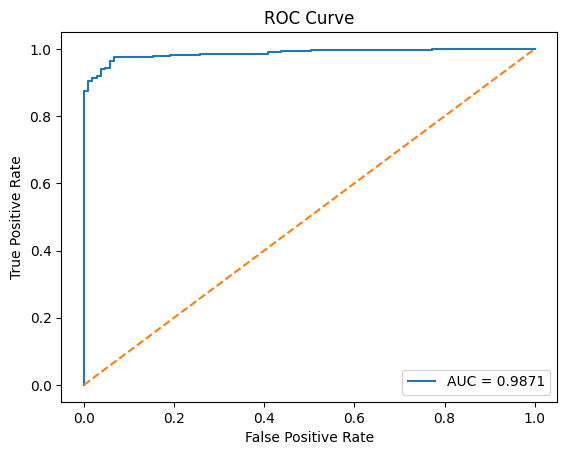

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

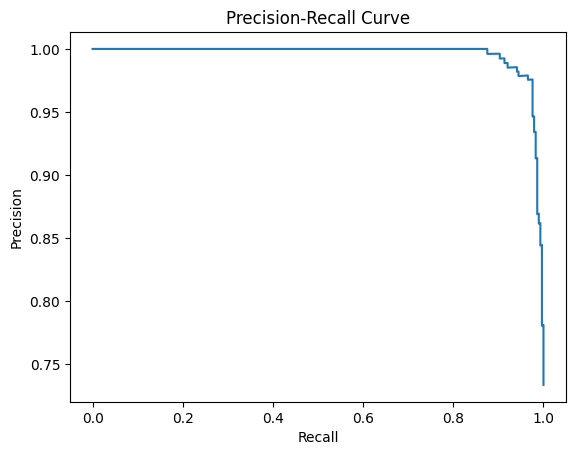

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

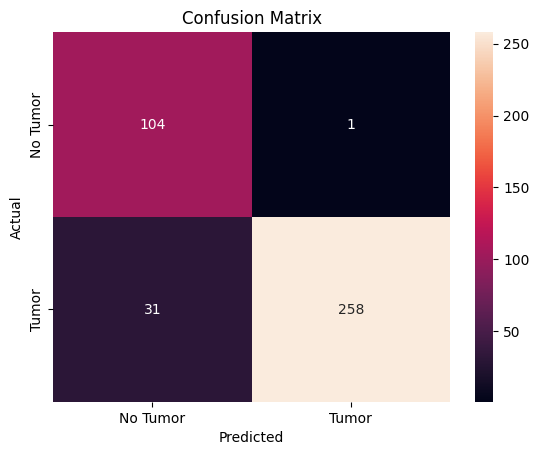

In [18]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Applying XAI methods

In [19]:
import methods as M
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os

In [20]:
root_dir = "BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData"

patients = sorted(os.listdir(root_dir))[:3]

data = [M.get_central_slice(os.path.join(root_dir, p)) for p in patients]

# ONLY FIRST PATIENT
img, gt = data[0]

In [21]:
last_conv_layer = "top_conv"

In [23]:
def preprocess_eff(img):
    x = np.expand_dims(img, axis=0)   # ADD BATCH DIM
    return tf.keras.applications.efficientnet.preprocess_input(x)

In [24]:
img_batch = preprocess_eff(img)

In [25]:
hm_gradcam = M.make_gradcam_heatmap(
    img_batch, model, last_conv_layer
)

hm_gcpp = M.gradcam_plus_plus(
    img_batch, model, last_conv_layer
)

hm_ig = M.integrated_gradients(
    model, img_batch
)

hm_sg = M.smoothgrad(
    model, img_batch
)

In [26]:
methods = {
    "GradCAM": M.prepare_heatmap(hm_gradcam),
    "GradCAM++": M.prepare_heatmap(hm_gcpp),
    "Integrated Gradients": M.prepare_heatmap(hm_ig),
    "SmoothGrad": M.prepare_heatmap(hm_sg),
}

In [27]:
overlays = {
    name: M.overlay_heatmap(img, hm)
    for name, hm in methods.items()
}

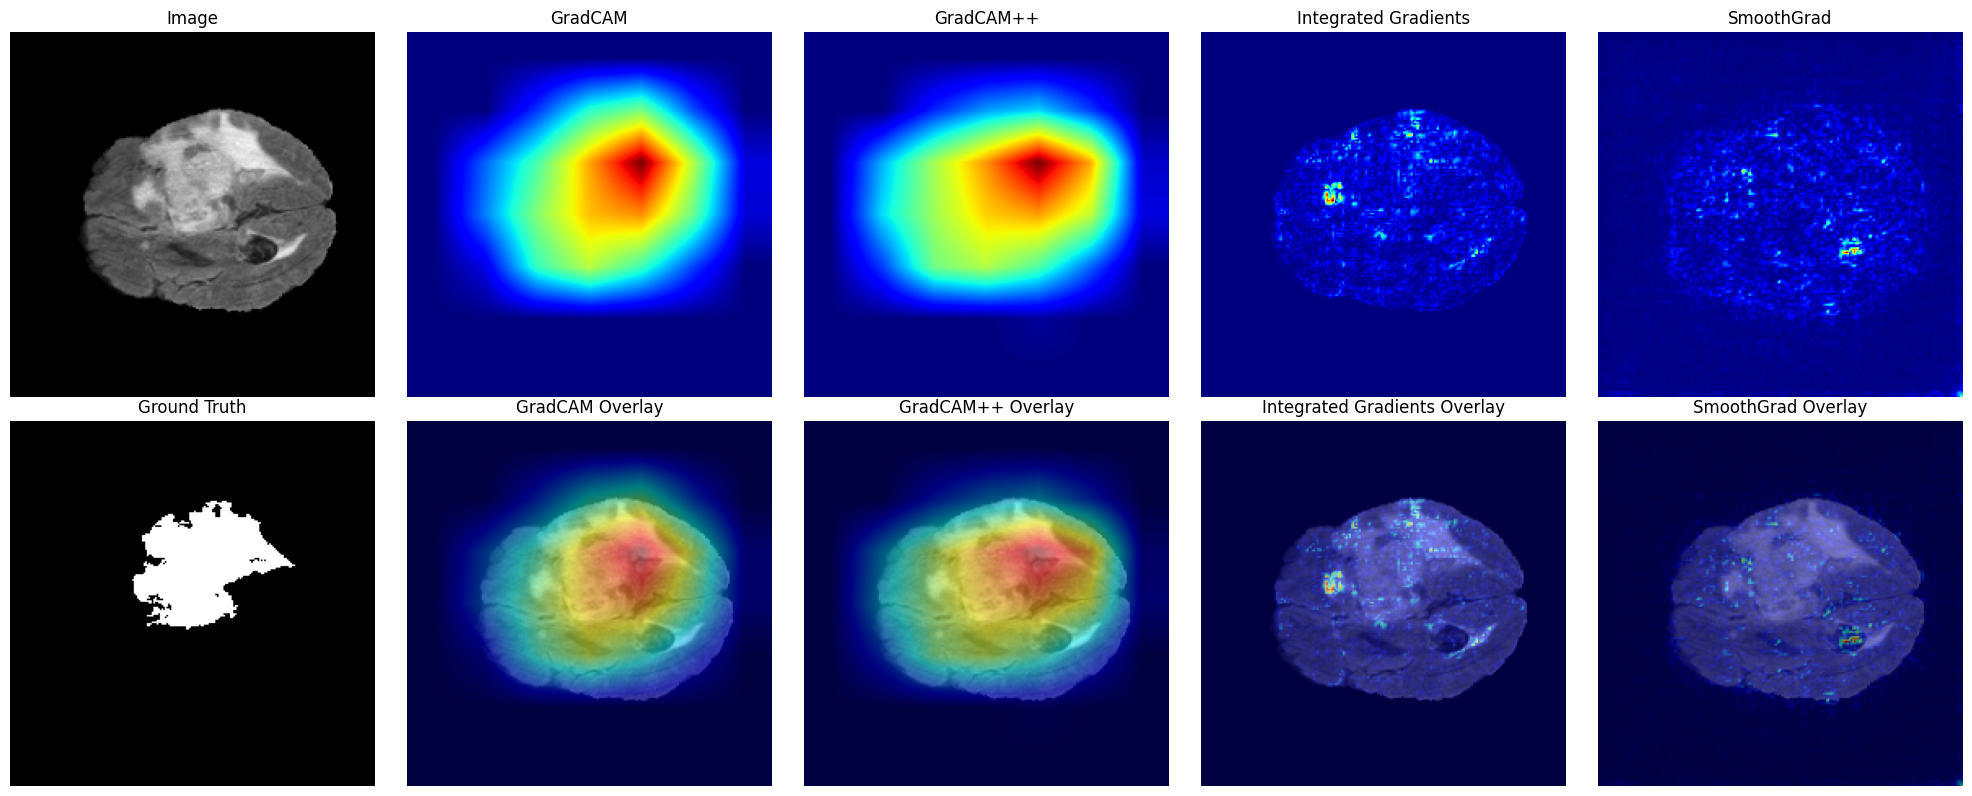

In [ ]:
plt.figure(figsize=(20,8))



plt.subplot(2,5,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

titles = ["GradCAM", "GradCAM++", "Integrated Gradients", "SmoothGrad"]

for i, t in enumerate(titles):
    plt.subplot(2,5,i+2)
    plt.imshow(methods[t], cmap="jet")
    plt.title(t)
    plt.axis("off")



plt.subplot(2,5,6)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

for i, t in enumerate(titles):
    plt.subplot(2,5,i+7)
    plt.imshow(overlays[t])
    plt.title(f"{t} Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

results = []

for idx, (img, gt) in enumerate(data):

    img_batch = preprocess_eff(img)

    # ---- Heatmaps ----
    hm_gradcam = M.make_gradcam_heatmap(img_batch, model, last_conv_layer)
    hm_gcpp    = M.gradcam_plus_plus(img_batch, model, last_conv_layer)
    hm_ig      = M.integrated_gradients(model, img_batch)
    hm_sg      = M.smoothgrad(model, img_batch)

    methods = {
        "GradCAM": M.prepare_heatmap(hm_gradcam),
        "GradCAM++": M.prepare_heatmap(hm_gcpp),
        "IG": M.prepare_heatmap(hm_ig),
        "SmoothGrad": M.prepare_heatmap(hm_sg),
    }

    # ---- Metrics ----
    for name, hm in methods.items():

        pred_mask = M.heatmap_to_mask(hm)

        dice = M.dice_score(gt, pred_mask)
        iou  = M.iou_score(gt, pred_mask)

        results.append({
            "Patient": idx+1,
            "Method": name,
            "Dice": dice,
            "IoU": iou
        })

In [31]:
df = pd.DataFrame(results)

df

,Patient,Method,Dice,IoU
0,1,GradCAM,0.605116,0.433811
1,1,GradCAM++,0.563333,0.392111
2,1,IG,0.043035,0.021991
3,1,SmoothGrad,0.004558,0.002284
4,2,GradCAM,0.340739,0.205356
5,2,GradCAM++,0.377699,0.232817
6,2,IG,0.128167,0.068471
7,2,SmoothGrad,0.001087,0.000544
8,3,GradCAM,0.169721,0.092729
9,3,GradCAM++,0.106884,0.056459


In [32]:
avg_df = df.groupby("Method")[["Dice","IoU"]].mean()
print("\nAverage Performance:\n")
avg_df


Average Performance:



,Dice,IoU
Method,,
GradCAM,0.371859,0.243965
GradCAM++,0.349305,0.227129
IG,0.096240,0.050963
SmoothGrad,0.007406,0.003728


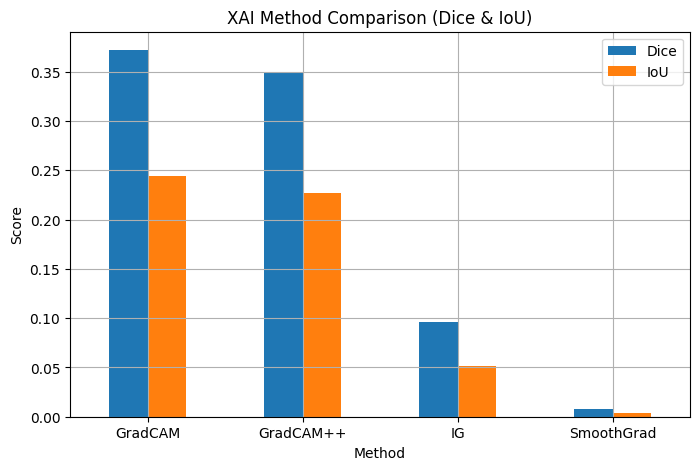

In [33]:
import matplotlib.pyplot as plt

avg_df.plot(kind="bar", figsize=(8,5))
plt.title("XAI Method Comparison (Dice & IoU)")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.grid()
plt.show()

### Faithfulness tests and comparison

In [52]:
import importlib
importlib.reload(M)
help(M.evaluate_setting)

Help on function evaluate_setting in module methods:

evaluate_setting(model, img, methods, del_fn, ins_fn, preprocess_fn, name)



In [53]:
import methods as M

In [54]:
preprocess = tf.keras.applications.efficientnet.preprocess_input

In [55]:
df_black = M.evaluate_setting(model, img, methods, M.deletion_pixel_black, M.insertion_pixel_black, preprocess, "Pixel Blackout")
df_black


Pixel Blackout Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.705544       0.076795
1   GradCAM++      0.799201       0.098815
2          IG      0.757408       0.014780
3  SmoothGrad      0.066759       0.011622


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.705544,0.076795
1,GradCAM++,0.799201,0.098815
2,IG,0.757408,0.014780
3,SmoothGrad,0.066759,0.011622


In [56]:
df_blur = M.evaluate_setting(model, img, methods, M.deletion_pixel_blur, M.insertion_pixel_blur, preprocess, "Pixel Blur")
df_blur


Pixel Blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.156191       0.130052
1   GradCAM++      0.106670       0.094518
2          IG      0.124600       0.079375
3  SmoothGrad      0.047004       0.160774


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.156191,0.130052
1,GradCAM++,0.106670,0.094518
2,IG,0.124600,0.079375
3,SmoothGrad,0.047004,0.160774


In [58]:
df_region = M.evaluate_setting(model, img, methods, M.deletion_region_blur, M.insertion_region_blur, preprocess, "Region blur")
df_region


Region blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.113223       0.115870
1   GradCAM++      0.083255       0.078255
2          IG      0.074986       0.082418
3  SmoothGrad      0.103904       0.077282


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.113223,0.115870
1,GradCAM++,0.083255,0.078255
2,IG,0.074986,0.082418
3,SmoothGrad,0.103904,0.077282


In [59]:
final_df = pd.concat([
    df_black.assign(Setting="Pixel Blackout"),
    df_blur.assign(Setting="Pixel Blur"),
    df_region.assign(Setting="Region Blur")
])
final_df

,Method,Deletion_AUC,Insertion_AUC,Setting
0,GradCAM,0.705544,0.076795,Pixel Blackout
1,GradCAM++,0.799201,0.098815,Pixel Blackout
2,IG,0.757408,0.014780,Pixel Blackout
3,SmoothGrad,0.066759,0.011622,Pixel Blackout
0,GradCAM,0.156191,0.130052,Pixel Blur
1,GradCAM++,0.106670,0.094518,Pixel Blur
2,IG,0.124600,0.079375,Pixel Blur
3,SmoothGrad,0.047004,0.160774,Pixel Blur
0,GradCAM,0.113223,0.115870,Region Blur
1,GradCAM++,0.083255,0.078255,Region Blur


In [60]:
pivot = final_df.pivot(index="Method", columns="Setting")
pivot

Deletion_AUC                         Insertion_AUC             \
Setting    Pixel Blackout Pixel Blur Region Blur Pixel Blackout Pixel Blur   
Method                                                                       
GradCAM          0.705544   0.156191    0.113223       0.076795   0.130052   
GradCAM++        0.799201   0.106670    0.083255       0.098815   0.094518   
IG               0.757408   0.124600    0.074986       0.014780   0.079375   
SmoothGrad       0.066759   0.047004    0.103904       0.011622   0.160774   

                        
Setting    Region Blur  
Method                  
GradCAM       0.115870  
GradCAM++     0.078255  
IG            0.082418  
SmoothGrad    0.077282

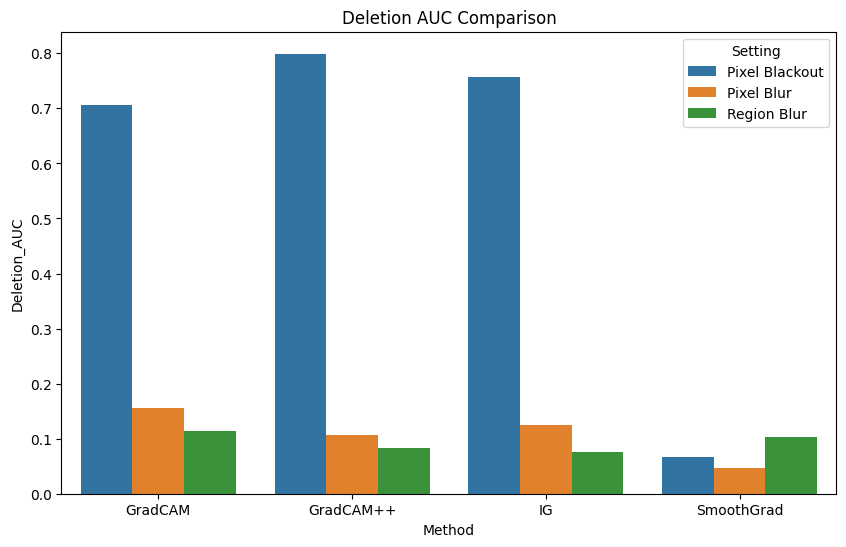

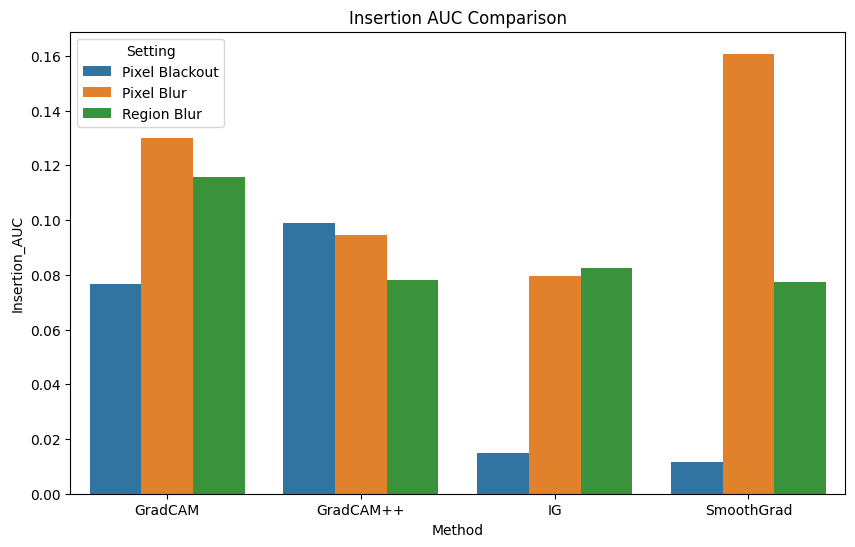

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Deletion_AUC", hue="Setting")
plt.title("Deletion AUC Comparison")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Insertion_AUC", hue="Setting")
plt.title("Insertion AUC Comparison")
plt.show()